# Project Demo

## Calcification-only final configuration
* Image View: CC-Only
* Lesion Type: Calcifications-Only
* Image Preprocessing: Baseline (resizing + model-specific normalization)
* Classification Threshold (optimal cutoff in ROC Curve): 0.36

## Mass-only final configuration
* Image View: CC-Only
* Lesion Type: Mass-Only
* Image Preprocessing: Baseline (resizing + model-specific normalization)
* Classification Threshold (optimal cutoff in ROC Curve): 0.35

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import MobileNetV2, ResNet50
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [2]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [3]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 896, done.
remote: Counting objects: 100% (203/203), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 896 (delta 87), reused 171 (delta 62), pack-reused 693 (from 2)
Receiving objects: 100% (896/896), 29.81 MiB | 30.22 MiB/s, done.
Resolving deltas: 100% (430/430), done.
/content/CM3070_Final_Project


In [4]:
# Add source code's path
sys.path.append('/content/CM3070_Final_Project')

In [5]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.final_results_functions import *
from src.visualizations import *
from src.calibration_scores_functions import *
from src.grad_cam_functions import *
from src.constants import BATCH_SIZE

### Load Dataset

In [6]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Unzip and extract testing dataset (containing images) and store it in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [8]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [9]:
# Extract testing metadata CSV file from drive and store it as a dataframe
test_df = pd.read_csv(dataset_root + "/test_data.csv")

### Update 'image_path' of the dataset

In [10]:
# Update 'image_path of testing dataframe with new image path source
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

### Image Preprocessor

In [11]:
# Image preprocessor
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

## Calcification-Only Final Configuration

### Calcification Lesion and CC View Data

In [12]:
# Calcification-only lesion with CC-Only view testing dataframe
test_df_c = test_df.loc[(test_df['abnormality type'] == 'calcification') & (test_df['image view'] == 'CC')]

### Test True Labels of Calcification Data

In [13]:
test_true_labels_c = test_df_c['pathology'].to_numpy()

### Tf.data Dataset Generation for Calcification Data

In [14]:
# Generate testing dataset for Calcification only
test_dataset_c = dataset_preparation(test_df_c, baseline_preprocessor, 0, BATCH_SIZE, training=False)

#### True label tensors of Calcification Data

In [15]:
# Testing true labels tensor preparation (calcification)
test_true_labels_tensor_c = tf.convert_to_tensor(test_df_c['pathology'], dtype=tf.float32)
test_true_labels_tensor_c = tf.reshape(test_true_labels_tensor_c, (-1, 1))

### Optimal Classification Threshold of Calcification-Only Final Configuration

In [16]:
THRESHOLD_C = 0.36

### Load Trained Calcification-only MobileNetV2

In [17]:
mobilenetv2_model = tf.keras.models.load_model("/content/drive/MyDrive/CM3070_Final_Project_Models/mobilenetv2_calcification.keras")

### Calcification-only Final Configuration Evaluations

In [18]:
# Get test logits, predictions and evaluation metrics using optimal threshold from ROC Curve as classification threshold
logits_c, preds_c, eval_metrics_c, _ = generate_predictions_and_evaluations(mobilenetv2_model, test_dataset_c, test_true_labels_c, THRESHOLD_C)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 451ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 322ms/step - auc: 0.6432 - loss: 0.5405 - precision: 0.7500 - recall: 0.3976


<Figure size 1000x600 with 0 Axes>

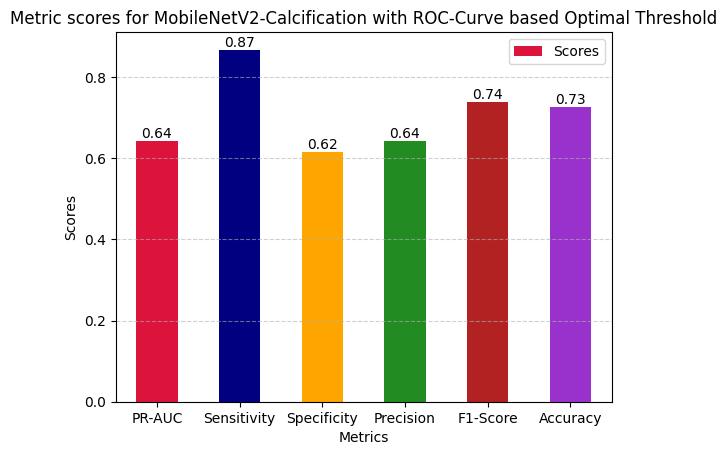

In [19]:
plot_metrics(eval_metrics_c, 'MobileNetV2-Calcification with ROC-Curve based Optimal Threshold')

### ECE Scores

In [20]:
# ECE Score for Calcification
with tf.device("/CPU:0"):
  ece_c = compute_ece_score(logits_c, test_true_labels_tensor_c, 10)

print(f"ECE Score Calcification-only Final Configuration: {ece_c}")

ECE Score Calcification-only Final Configuration: 0.05073891207575798


### Patient-Level Evaluations

In [21]:
patient_level_metrics_c = patient_level_evaluation_metrics(mobilenetv2_model, test_df_c, test_dataset_c, THRESHOLD_C)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step


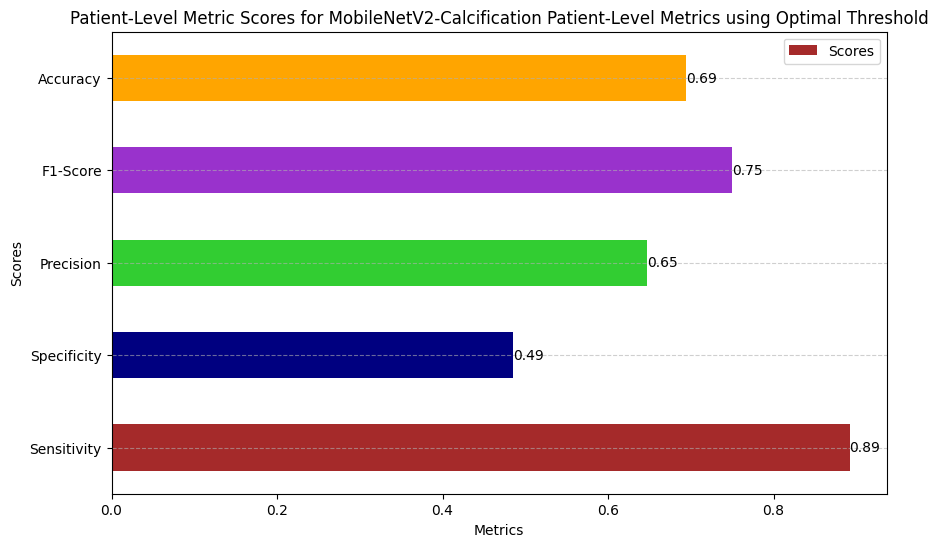

In [22]:
plot_patient_level_metrics(patient_level_metrics_c, 'MobileNetV2-Calcification Patient-Level Metrics using Optimal Threshold')

### Grad CAM Explainability

In [23]:
# Extract base model and its last convolutional layer
base_mobilenetv2 = mobilenetv2_model.get_layer('mobilenetv2_1.00_224')
last_conv_layer_name_c = 'Conv_1'

In [24]:
# Create a copy of test_df_c and add predictions to the copied dataframe
test_gc_c = test_df_c.copy()
test_gc_c['prediction'] = preds_c

In [25]:
# Sample 1 randomly selected image
sample_c = test_gc_c.sample(n=1, random_state=42)[['new_image_path', 'abnormality type', 'pathology', 'prediction']]

#### Sample Calcification

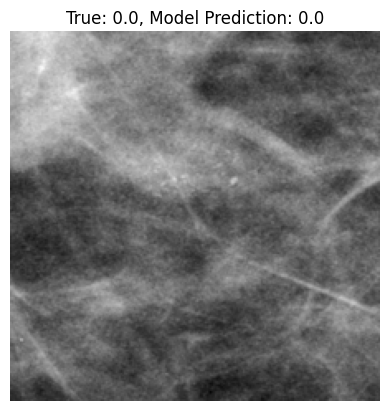

In [26]:
# Original
original_c = tf.keras.utils.load_img(sample_c.iloc[0]['new_image_path'])
original_c = original_c.resize((224, 224))
plt.imshow(original_c)
plt.title(f"True: {sample_c.iloc[0]['pathology']}, Model Prediction: {sample_c.iloc[0]['prediction']}")
plt.axis('off')
plt.show()

In [27]:
# Grad CAM Results for calcification
sample_gc_c, pred_gc_c = generate_grad_cam_image(sample_c['new_image_path'].iloc[0], mobilenetv2_model, base_mobilenetv2, last_conv_layer_name_c)

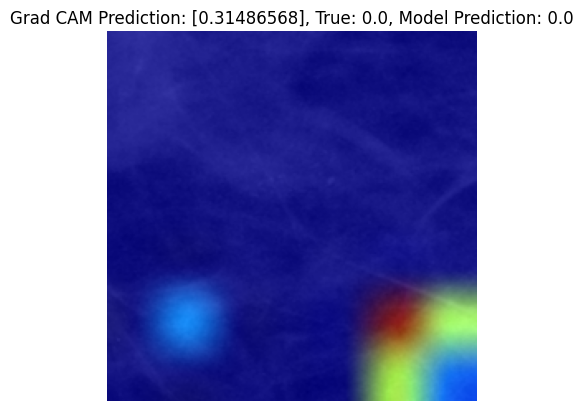

In [28]:
# Visualize Grad CAM for calcification image
plt.imshow(sample_gc_c)
plt.title(f"Grad CAM Prediction: {pred_gc_c}, True: {sample_c.iloc[0]['pathology']}, Model Prediction: {sample_c.iloc[0]['prediction']}")
plt.axis('off')
plt.show()

## Mass-Only Final Configuration

### Mass Lesion and CC View Data

In [29]:
# Mass-only lesion with CC-Only view testing dataframe
test_df_m = test_df.loc[(test_df['abnormality type'] == 'mass') & (test_df['image view'] == 'CC')]

### Test True Labels of Mass Data

In [30]:
# Testing set true labels for evaluation
test_true_labels_m = test_df_m['pathology'].to_numpy()

### Tf.data Dataset Generation for Mass Data

In [31]:
# Generate testing dataset for Mass only
test_dataset_m = dataset_preparation(test_df_m, baseline_preprocessor, 0, BATCH_SIZE, training=False)

#### True label tensors of Mass Data

In [32]:
# Testing true labels tensor preparation (mass)
test_true_labels_tensor_m = tf.convert_to_tensor(test_df_m['pathology'], dtype=tf.float32)
test_true_labels_tensor_m = tf.reshape(test_true_labels_tensor_m, (-1, 1))

### Optimal Classification Thresholds of Mass-Only Final Configuration

In [33]:
THRESHOLD_M = 0.35

### Load Trained Mass-only ResNet50

In [34]:
resnet50_model = tf.keras.models.load_model("/content/drive/MyDrive/CM3070_Final_Project_Models/resnet50_mass.keras")

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


### Mass-only Final Configuration Evaluations

In [35]:
# Get test logits, predictions and evaluation metrics using optimal threshold from ROC Curve as classification threshold
logits_m, preds_m, eval_metrics_m, _ = generate_predictions_and_evaluations(resnet50_model, test_dataset_m, test_true_labels_m, THRESHOLD_M)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 651ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - auc: 0.7150 - loss: 0.5748 - precision: 0.7727 - recall: 0.4928


<Figure size 1000x600 with 0 Axes>

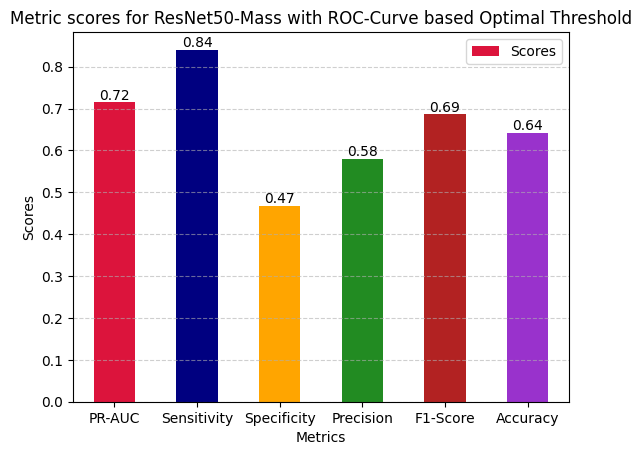

In [36]:
plot_metrics(eval_metrics_m, 'ResNet50-Mass with ROC-Curve based Optimal Threshold')

### ECE Scores

In [37]:
# ECE Score before temperature scaling
with tf.device("/CPU:0"):
  ece_m = compute_ece_score(logits_m, test_true_labels_tensor_m, 10)

print(f"ECE Score Mass-only Final Configuration: {ece_m}")

ECE Score Mass-only Final Configuration: 0.049938566982746124


### Patient-Level Evaluations

In [38]:
patient_level_metrics_m = patient_level_evaluation_metrics(resnet50_model, test_df_m, test_dataset_m, THRESHOLD_M)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step


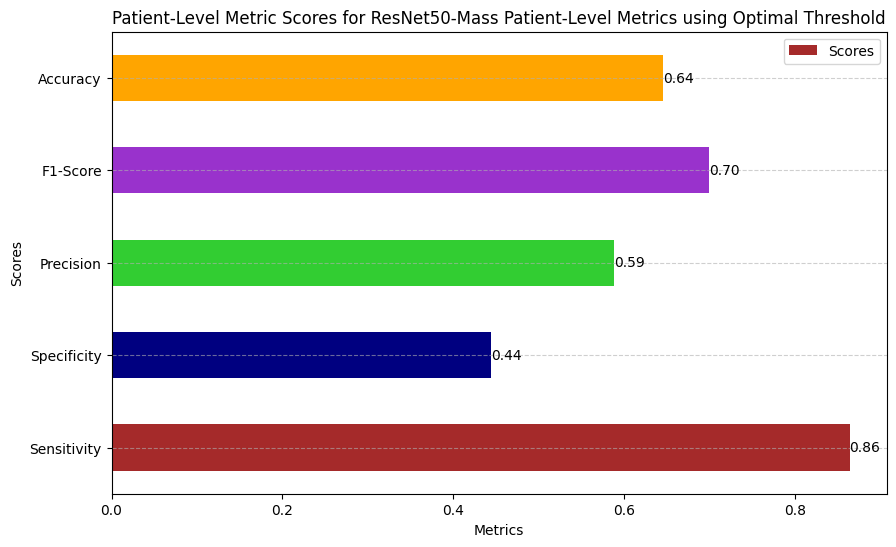

In [39]:
plot_patient_level_metrics(patient_level_metrics_m, 'ResNet50-Mass Patient-Level Metrics using Optimal Threshold')

### Grad CAM Explainability

In [40]:
# Extract base model and its last convolutional layer
base_resnet50 = resnet50_model.get_layer('resnet50')
last_conv_layer_name_m = 'conv5_block3_out'

In [41]:
# Create a copy of test_df_m and add predictions to the copied dataframe
test_gc_m = test_df_m.copy()
test_gc_m['prediction'] = preds_m

In [42]:
# Sample 1 randomly selected image
sample_m = test_gc_m.sample(n=1, random_state=42)[['new_image_path', 'abnormality type', 'pathology', 'prediction']]

#### Sample Mass

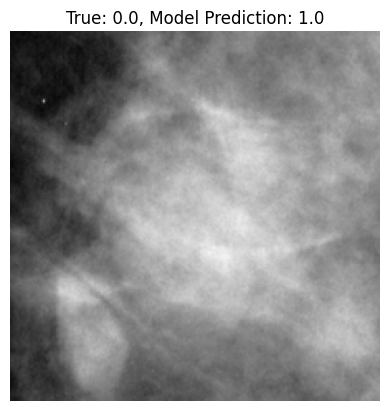

In [43]:
# Original
original_m = tf.keras.utils.load_img(sample_m.iloc[0]['new_image_path'])
original_m = original_m.resize((224, 224))
plt.imshow(original_m)
plt.title(f"True: {sample_m.iloc[0]['pathology']}, Model Prediction: {sample_m.iloc[0]['prediction']}")
plt.axis('off')
plt.show()

In [44]:
# Grad CAM Results for mass
sample_gc_m, pred_gc_m = generate_grad_cam_image(sample_m['new_image_path'].iloc[0], resnet50_model, base_resnet50, last_conv_layer_name_m)

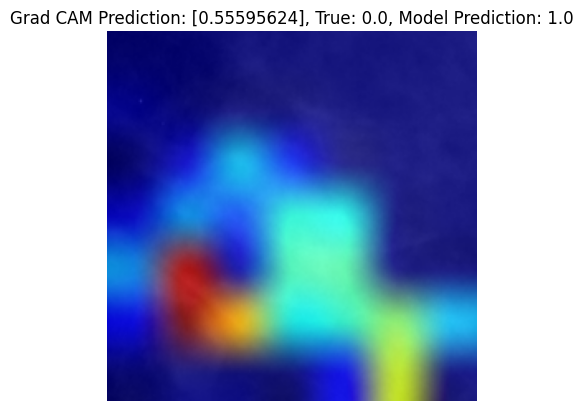

In [45]:
# Visualize Grad CAM for mass image
plt.imshow(sample_gc_m)
plt.title(f"Grad CAM Prediction: {pred_gc_m}, True: {sample_m.iloc[0]['pathology']}, Model Prediction: {sample_m.iloc[0]['prediction']}")
plt.axis('off')
plt.show()